In [1]:
import pandas as pd
dataset = pd.read_csv("50_Startups_dataset.csv")
dataset

,Unnamed: 0,R&D Spend,Administration,Marketing Spend,State,Profit
0,0,165349.30,136897.90,471784.20,New York,192261.93
1,1,162597.80,151377.69,443898.63,California,191792.16
2,2,153441.61,101145.65,407934.64,Florida,191050.49
3,3,144372.51,118671.95,383199.72,New York,182902.09
4,4,142107.44,91391.87,366168.52,Florida,166188.04
5,5,131877.00,99814.81,362861.46,New York,156991.22
6,6,134615.56,147198.97,127716.92,California,156122.61
7,7,130298.23,145530.16,323876.78,Florida,155752.70
8,8,120542.62,148719.05,311613.39,New York,152211.87
9,9,123334.98,108679.27,304981.72,California,149760.06


In [2]:
dataset = dataset.drop(columns=["Unnamed: 0"])

In [3]:
dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.30,136897.90,471784.20,New York,192261.93
1,162597.80,151377.69,443898.63,California,191792.16
2,153441.61,101145.65,407934.64,Florida,191050.49
3,144372.51,118671.95,383199.72,New York,182902.09
4,142107.44,91391.87,366168.52,Florida,166188.04
5,131877.00,99814.81,362861.46,New York,156991.22
6,134615.56,147198.97,127716.92,California,156122.61
7,130298.23,145530.16,323876.78,Florida,155752.70
8,120542.62,148719.05,311613.39,New York,152211.87
9,123334.98,108679.27,304981.72,California,149760.06


In [10]:
dataset = dataset.drop(columns=["State"])
dataset

,R&D Spend,Administration,Marketing Spend,Profit
0,165349.30,136897.90,471784.20,192261.93
1,162597.80,151377.69,443898.63,191792.16
2,153441.61,101145.65,407934.64,191050.49
3,144372.51,118671.95,383199.72,182902.09
4,142107.44,91391.87,366168.52,166188.04
5,131877.00,99814.81,362861.46,156991.22
6,134615.56,147198.97,127716.92,156122.61
7,130298.23,145530.16,323876.78,155752.70
8,120542.62,148719.05,311613.39,152211.87
9,123334.98,108679.27,304981.72,149760.06


In [12]:
dataset.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
Profit             0
dtype: int64

In [13]:
#we can handle through supervised learning


In [24]:
independent = dataset[["R&D Spend","Administration","Marketing Spend"]]
dependent = dataset[["Profit"]]

In [25]:
import matplotlib.pyplot as plt

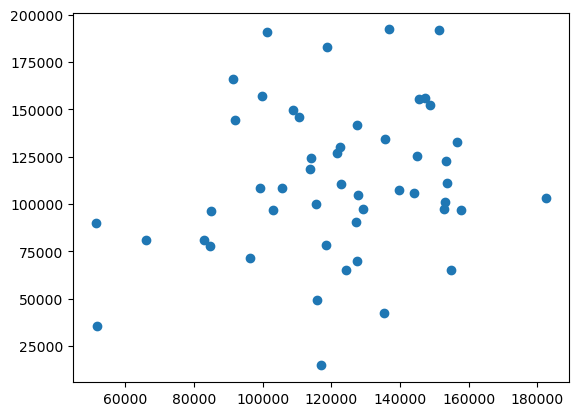

In [23]:
plt.scatter(dataset["Administration"],dataset["Profit"])
plt.show()

In [27]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(independent,dependent,test_size=0.3,random_state=22)

In [30]:
x_train

,R&D Spend,Administration,Marketing Spend
23,67532.63,105751.13,304768.83
11,100672.06,91790.71,249744.65
9,123334.98,108679.27,304981.72
10,101913.18,110594.21,229161.05
37,44070.05,51283.24,197029.52
21,78389.57,153773.53,299737.39
7,130298.23,145530.16,323876.78
28,66051.62,182645.66,118148.30
40,28754.43,118546.15,172795.77
19,86419.80,153514.21,0.10


In [36]:
x_test

,R&D Spend,Administration,Marketing Spend
32,63408.96,129219.71,46085.35
12,93863.85,127320.48,249839.54
25,64664.81,139553.26,137962.72
47,0.10,135427.02,0.10
33,55494.05,103057.59,214634.91
22,73994.66,122782.85,303319.36
3,144372.51,118671.95,383199.72
30,61994.58,115641.38,91131.34
26,75328.97,144136.08,134050.17
1,162597.80,151377.69,443898.63


In [37]:
y_train

,Profit
23,108734.09
11,144259.50
9,149760.06
10,146122.05
37,89949.24
21,111313.12
7,155752.70
28,103282.48
40,78240.01
19,122776.96


In [38]:
y_test

,Profit
32,97427.94
12,141585.62
25,107404.44
47,42559.83
33,96779.02
22,110352.35
3,182902.09
30,99937.69
26,105733.64
1,191792.16


In [49]:
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
wight=regressor.coef_
print(wight)
bais=regressor.intercept_
print(bais)

[[ 0.77221228 -0.01838001  0.01728631]]
[53614.44354615]


In [50]:
y_pred = regressor.predict(x_test)
y_pred

array([[101001.20638343],
       [128075.91267245],
       [103369.27925008],
       [ 51125.37184251],
       [ 98283.6761594 ],
       [113740.5508079 ],
       [169543.58574451],
       [100937.25373106],
       [111452.40865191],
       [184065.50671669],
       [ 91136.58058385],
       [ 76439.8826756 ],
       [116191.8055472 ],
       [ 52245.23227327],
       [126529.41688541]])

In [51]:
y_test

,Profit
32,97427.94
12,141585.62
25,107404.44
47,42559.83
33,96779.02
22,110352.35
3,182902.09
30,99937.69
26,105733.64
1,191792.16


In [54]:
from sklearn.metrics import r2_score
model = r2_score(y_test, y_pred)*100

In [55]:
model

92.49233974958787

In [56]:
import pickle
filename = "shyam.sav"
pickle.dump(regressor,open(filename,"wb"))

In [64]:
loaded_model=pickle.load(open("shyam.sav","rb"))
result=loaded_model.predict([[20,50,100]])
result

C:\Users\acer\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[53630.69742212]])